In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1785898957.650746   78534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785898957.702578   78534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785898959.420961   78534 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
Titanics = pd.read_csv("~/Projects/Code/test/Titanic-Dataset.csv")

In [3]:
Titanics.info(), Titanics.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


(None, (891, 12))

In [4]:
Titanics.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
Titanics.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
Titanics.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
Titanics.describe(include="object")

/tmp/ipykernel_78534/1974910751.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Titanics.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


# Visualize to watch relation ship between columns

<Axes: ylabel='Age'>

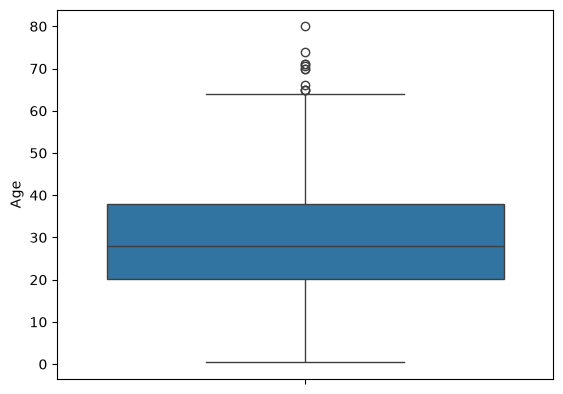

In [8]:
import seaborn as sns

sns.boxplot(Titanics["Age"])

<Axes: xlabel='Sex', ylabel='count'>

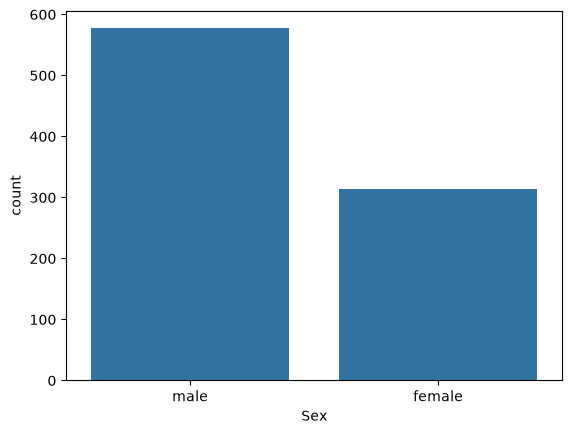

In [9]:
sns.countplot(Titanics, x="Sex")

<Axes: xlabel='Embarked', ylabel='count'>

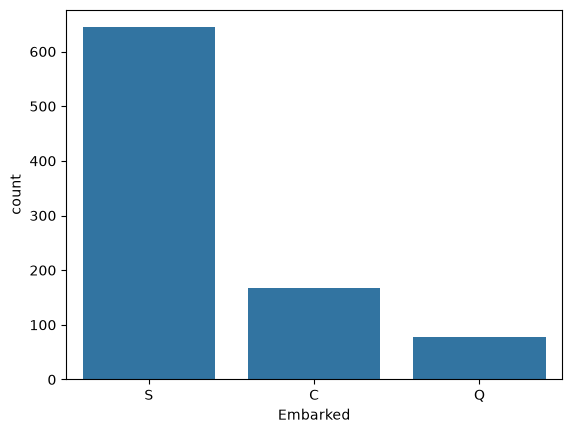

In [10]:
sns.countplot(Titanics, x="Embarked")

### Visualize relation ship with targer

<Axes: xlabel='Sex', ylabel='count'>

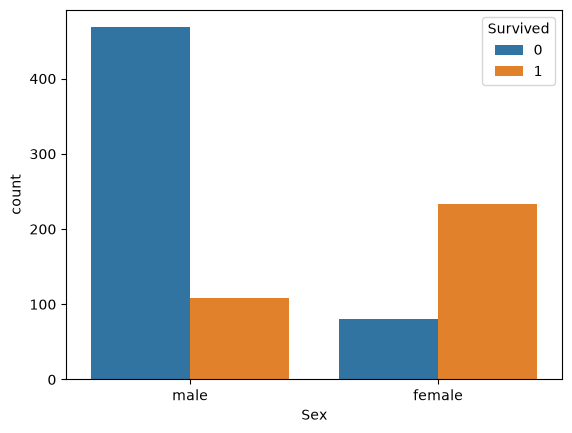

In [11]:
sns.countplot(Titanics,x="Sex", hue="Survived")

<Axes: xlabel='Age', ylabel='count'>

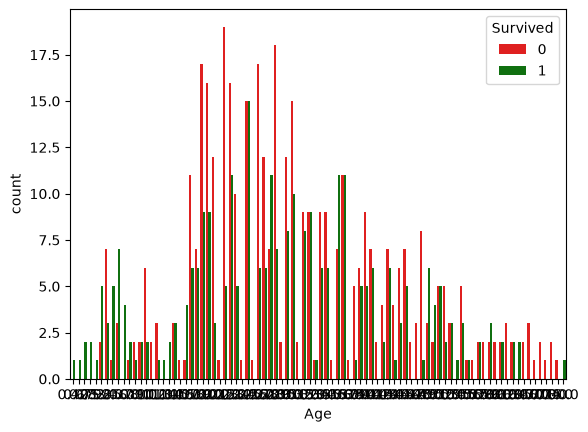

In [12]:
sns.countplot(Titanics, x="Age", hue="Survived", palette=["red", "green"])

# Preprocessing Data

In [13]:
Titanics = Titanics.drop(columns= ["PassengerId", "Name", "Ticket","Cabin"])

In [14]:
Titanics.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [15]:
Titanics.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [16]:
Titanics.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [17]:
#Define Preprocessing Steps
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import numpy as np


num_feature = ["Age", "SibSp", "Parch", "Fare"]

cate_feature = ["Pclass","Sex", "Embarked"]

# Define pipline
num_pipline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="uniform", metric="nan_euclidean")),
    ("scaler", StandardScaler())
])

cate_pipline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#Prcessor

processor = ColumnTransformer(
    transformers=[
        ('num', num_pipline, num_feature),
        ('cate', cate_pipline, cate_feature)
    ]
)


# Split train amd test set

In [28]:
from sklearn.model_selection import train_test_split

X = Titanics.drop("Survived", axis=1)
y = Titanics["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
print(type(X_train))
print(type(X_test))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [ ]:
X_train = processor.fit_transform(X_train)
X_test = processor.transform(X_test)


# Train model

In [ ]:
import tensorflow as tf


tf.random.set_seed(42)

Titanics_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

Titanics_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


history = Titanics_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test)
)


In [55]:
#model 2
tf.random.set_seed(42)
Titanics_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

Titanics_model_2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

callback = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 10,
    restore_best_weights = True
)

history_2 = Titanics_model_2.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test))

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7051 - loss: 0.6388 - val_accuracy: 0.7374 - val_loss: 0.5815
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7935 - loss: 0.5367 - val_accuracy: 0.7877 - val_loss: 0.5168
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8076 - loss: 0.4761 - val_accuracy: 0.8156 - val_loss: 0.4804
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.4441 - val_accuracy: 0.8156 - val_loss: 0.4638
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8118 - loss: 0.4281 - val_accuracy: 0.8212 - val_loss: 0.4561
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8188 - loss: 0.4182 - val_accuracy: 0.8101 - val_loss: 0.4516
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8188 - loss: 0.4109 - val_accuracy: 0.7989 - val_loss: 0.4484
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8216 - loss: 0.4050 - val_accuracy: 0.7989 - v

In [56]:
y_prob_2 = Titanics_model_2.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [42]:
y_prob = Titanics_model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [43]:

y_pred = (y_prob > 0.5).astype(int)

In [57]:
y_pred_2 = (y_prob_2 > 0.5).astype(int)

In [47]:
y_pred.squeeze()

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy_2 = accuracy_score(y_test,y_pred_2)

accuracy
accuracy_2

0.8044692737430168

In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[98, 12],
       [24, 45]])

In [52]:
from sklearn.metrics import classification_report

classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.80      0.89      0.84       110\n           1       0.79      0.65      0.71        69\n\n    accuracy                           0.80       179\n   macro avg       0.80      0.77      0.78       179\nweighted avg       0.80      0.80      0.79       179\n'

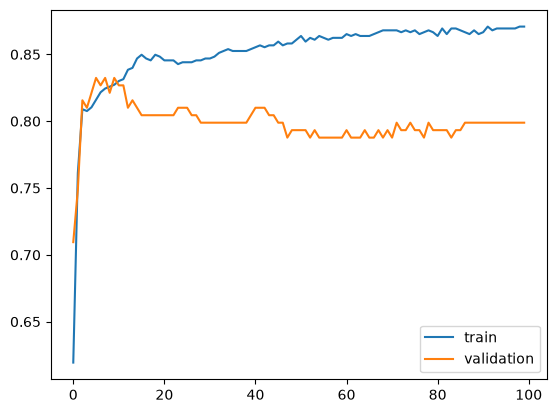

In [53]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.show()